# 

In [1]:
import os
os.chdir("..")  # go up one level

In [2]:
import glob
import json
import pandas as pd
import re

paths = glob.glob("calibrationData/**/metadata.json", recursive=True)

rows = []

for path in paths:
    try:
        with open(path, "r") as f:
            data = json.load(f)
        
        data["folder"] = path.rsplit("/", 1)[0]  # keep folder info
        rows.append(data)
        
    except Exception as e:
        print(f"Error reading {path}: {e}")

df = pd.DataFrame(rows)
df["dataset"] = df["dataset"].fillna("gsm8k")


def get_model_size(model_name):
    match = re.search(r"([\d.]+)\s*B", model_name)
    return float(match.group(1)) if match else None

df["model_size"] = df["model"].apply(get_model_size)
    
df = df.set_index( ["model", "dataset"])
df_thinking = df[df["thinking"] == True]
df = df[df["thinking"] == False]
df = df.sort_index()

In [3]:
df

batch_size  thinking  \
model           dataset                         
Qwen/Qwen3-0.6B ai2_arc          16     False   
                gsm8k            16     False   
Qwen/Qwen3-1.7B ai2_arc          16     False   
                gsm8k            16     False   
Qwen/Qwen3-14B  ai2_arc          32     False   
                gsm8k            16     False   
Qwen/Qwen3-32B  ai2_arc          16     False   
                gsm8k            16     False   
Qwen/Qwen3-4B   ai2_arc           8     False   
                gsm8k             8     False   
Qwen/Qwen3-8B   ai2_arc          10     False   
                gsm8k            10     False   

                                                             system_prompt  \
model           dataset                                                      
Qwen/Qwen3-0.6B ai2_arc  Answer the following multiple-choice question....   
                gsm8k    Solve the following math problem.\n\nPlease re...   
Qwen/Qwen3-1.7B ai2_arc  Answer the following multiple-choice question....   
                gsm8k    Solve the following math problem.\n\nPlease re...   
Qwen/Qwen3-14B  ai2_arc  Answer the following multiple-choice question....   
                gsm8k    Solve the following math problem.\n\nPlease re...   
Qwen/Qwen3-32B  ai2_arc  Answer the following multiple-choice question....   
                gsm8k    Solve the following math problem.\n\nPlease re...   
Qwen/Qwen3-4B   ai2_arc  Answer the following multiple-choice question....   
                gsm8k    Solve the following math problem.\n\nPlease re...   
Qwen/Qwen3-8B   ai2_arc  Answer the following multiple-choice question....   
                gsm8k    Solve the following math problem.\n\nPlease re...   

                               timestamp device max_samples  \
model           dataset                                       
Qwen/Qwen3-0.6B ai2_arc  20260412_173401   cuda        None   
                gsm8k    20260412_172655   cuda        None   
Qwen/Qwen3-1.7B ai2_arc  20260412_174219   cuda        None   
                gsm8k    20260412_173709   cuda        None   
Qwen/Qwen3-14B  ai2_arc  20260412_230850   cuda        None   
                gsm8k    20260412_230544   cuda        None   
Qwen/Qwen3-32B  ai2_arc  20260412_231615   cuda        None   
                gsm8k    20260412_231005   cuda        None   
Qwen/Qwen3-4B   ai2_arc  20260412_181323   cuda        None   
                gsm8k    20260412_180144   cuda        None   
Qwen/Qwen3-8B   ai2_arc  20260412_224931   cuda        None   
                gsm8k    20260412_224214   cuda        None   

                                                       git_commit  \
model           dataset                                             
Qwen/Qwen3-0.6B ai2_arc  6f342c5335676860eb0027d2782c06880a1bf736   
                gsm8k    6f342c5335676860eb0027d2782c06880a1bf736   
Qwen/Qwen3-1.7B ai2_arc  6f342c5335676860eb0027d2782c06880a1bf736   
                gsm8k    6f342c5335676860eb0027d2782c06880a1bf736   
Qwen/Qwen3-14B  ai2_arc  919bb527671ef5c00d1173b42d6034a4667c9e4d   
                gsm8k    919bb527671ef5c00d1173b42d6034a4667c9e4d   
Qwen/Qwen3-32B  ai2_arc  919bb527671ef5c00d1173b42d6034a4667c9e4d   
                gsm8k    919bb527671ef5c00d1173b42d6034a4667c9e4d   
Qwen/Qwen3-4B   ai2_arc  4c5ae904330ede24ab6a356c7cd4a1ae246b58e8   
                gsm8k    4c5ae904330ede24ab6a356c7cd4a1ae246b58e8   
Qwen/Qwen3-8B   ai2_arc  919bb527671ef5c00d1173b42d6034a4667c9e4d   
                gsm8k    919bb527671ef5c00d1173b42d6034a4667c9e4d   

                                                      folder dataset_config  \
model           dataset                                                       
Qwen/Qwen3-0.6B ai2_arc  calibrationData/run_20260412_173401  ARC-Challenge   
                gsm8k    calibrationData/run_20260412_172655            NaN   
Qwen/Qwen3-1.7B ai2_arc  calibrationData/run_20260412_174219  ARC-Challenge   


In [4]:
import numpy as np
import re

def preprocess_gsm8k(df):
    df["log_conf"] = df["logprobs"].apply(lambda xs: np.exp(sum(xs)/len(xs)) if xs else 0.5)
    
    
    def extract_answer(text):
        match = re.search(r"####\s*(\-?\d+\.?\d*)", text)
        return float(match.group(1)) if match else None
    
    df["full_answer"] = df["answer"]
    df["answer"] = df["full_answer"].apply(extract_answer)
    
    def parse_prediction(pred):
        match = re.findall(r"-?\d+\.?\d*", str(pred))
        return float(match[-1]) if match else None
    
    df["prediction"] = df["prediction"].apply(parse_prediction)
    df["correct"] = df["answer"] == df["prediction"]

In [5]:
def preprocess_ai2_arc(df):
    df["correct"] = df["answer"] == df["prediction"]
    
    def get_log_conf(row):
        labels = row["labels"]
        probs = row["label_probs"]
        prediction = row["prediction"][0]
    
        try:
            idx = labels.index(prediction)
            return probs[idx]
        except:
            print(labels, probs, prediction)
        
    df["log_conf"] = df.apply(get_log_conf, axis=1)

In [ ]:
import numpy as np
import pandas as pd
from src import metrics

records = []
datasets = df.index.get_level_values("dataset").unique()

for dataset in datasets:
    files = df.xs(dataset, level="dataset")

    for model, row in files.iterrows():
        file = f"{row['folder']}/outputs.jsonl"
        output_file = pd.read_json(file, lines=True)

        if dataset == "gsm8k":
            preprocess_gsm8k(output_file)
        elif dataset == "ai2_arc":
            preprocess_ai2_arc(output_file)
        else:
            raise ValueError(f"Unknown dataset: {dataset}")

        rec = {
            "model": model,
            "dataset": dataset,
            "model_size": row["model_size"],
            "acc": output_file["correct"].mean(),
            "num_samples": len(output_file),
        }

        for method in ["verb", "log"]:
            conf_col = f"{method}_conf"
            mask = output_file[conf_col].notna()

            y_true = output_file.loc[mask, "correct"].to_numpy()
            y_conf = output_file.loc[mask, conf_col].to_numpy()

            # metrics
            ece_values = metrics.bootstrap_ece(y_true, y_conf, n_bootstrap=10)
            rec[f"{method}_ece"] = ece_values["ece"]
            rec[f"{method}_ece_se"] = ece_values["se"]
            rec[f"{method}_brier"] = metrics.brier_score_loss(y_true, y_conf)
            rec[f"{method}_ap"] = metrics.average_precision_score(y_true, y_conf)

            # calibration bins (equal-frequency / deciles)
            if len(y_conf) == 0:
                rec[f"{method}_bin_conf"] = [np.nan] * 10
                rec[f"{method}_bin_acc"] = [np.nan] * 10
            else:
                cal_df = pd.DataFrame({
                    "conf": y_conf,
                    "correct": y_true,
                }).sort_values("conf")

                # qcut on rank index → stable 10 equal-frequency bins
                cal_df["pool"] = pd.qcut(
                    np.arange(len(cal_df)),
                    q=10,
                    labels=False
                )

                pool_stats = (
                    cal_df.groupby("pool")
                    .agg(
                        avg_conf=("conf", "mean"),
                        avg_acc=("correct", "mean"),
                    )
                    .reindex(range(10))  # ensure all bins exist
                )

                rec[f"{method}_bin_conf"] = pool_stats["avg_conf"].tolist()
                rec[f"{method}_bin_acc"] = pool_stats["avg_acc"].tolist()

        records.append(rec)

summary = pd.DataFrame.from_records(records).set_index(["model", "dataset"])
summary

,,model_size,acc,num_samples,verb_ece,verb_ece_se,verb_brier,verb_ap,verb_bin_conf,verb_bin_acc,log_ece,log_ece_se,log_brier,log_ap,log_bin_conf,log_bin_acc
model,dataset,,,,,,,,,,,,,,,
Qwen/Qwen3-0.6B,gsm8k,0.6,0.043973,1319,0.931592,0.004890,0.914516,0.039465,"[0.8981568181818183, 0.9500000000000001, 0.972...","[0.045454545454545456, 0.06060606060606061, 0....",0.371240,0.009806,0.243020,0.034316,"[0.026998037448793533, 0.10988613415293015, 0....","[0.11363636363636363, 0.05303030303030303, 0.0..."
Qwen/Qwen3-1.7B,gsm8k,1.7,0.134193,1319,0.862820,0.007299,0.860543,0.136316,"[0.9701515151515152, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.11363636363636363, 0.18181818181818182, 0.1...",0.304363,0.011552,0.287598,0.128946,"[0.0033109281660004047, 0.02165436377262616, 0...","[0.23484848484848486, 0.12121212121212122, 0.1..."
Qwen/Qwen3-14B,gsm8k,14.0,0.369977,1319,0.580167,0.015292,0.569534,0.372429,"[0.9488636363636365, 0.9500000000000001, 0.950...","[0.3181818181818182, 0.4015151515151515, 0.356...",0.299375,0.010979,0.329932,0.513876,"[0.018218431031008418, 0.08915842751913106, 0....","[0.32575757575757575, 0.23484848484848486, 0.3..."
Qwen/Qwen3-32B,gsm8k,32.0,0.407885,1319,0.543306,0.017015,0.536768,0.409432,"[0.9500000000000001, 0.9500000000000001, 0.950...","[0.4015151515151515, 0.3939393939393939, 0.378...",0.169950,0.009813,0.243293,0.608215,"[0.07085042937626575, 0.14960146721347245, 0.2...","[0.19696969696969696, 0.2196969696969697, 0.26..."
Qwen/Qwen3-4B,gsm8k,4.0,0.230478,1319,0.721842,0.011098,0.698380,0.232382,"[0.9500000000000001, 0.9500000000000001, 0.950...","[0.20454545454545456, 0.22727272727272727, 0.2...",0.523469,0.014858,0.487703,0.383623,"[0.0356325832169099, 0.22428633501552772, 0.47...","[0.15151515151515152, 0.09848484848484848, 0.1..."
Qwen/Qwen3-8B,gsm8k,8.0,0.282790,1319,0.677346,0.012402,0.659915,0.310265,"[0.9500000000000001, 0.9500000000000001, 0.950...","[0.3181818181818182, 0.26515151515151514, 0.16...",0.337901,0.008996,0.333472,0.234297,"[3.386657602536465e-05, 0.0001923437156015775,...","[0.38636363636363635, 0.3787878787878788, 0.37..."
Qwen/Qwen3-0.6B,ai2_arc,0.6,0.584471,1172,0.394369,0.016170,0.398188,0.596514,"[0.8897457627118645, 0.9500000000000001, 0.980...","[0.5423728813559322, 0.6153846153846154, 0.547...",0.293429,0.008993,0.312380,0.766386,"[0.4069896633342161, 0.6745083800747863, 0.812...","[0.3389830508474576, 0.37606837606837606, 0.42..."
Qwen/Qwen3-1.7B,ai2_arc,1.7,0.759386,1172,0.189309,0.011983,0.216455,0.775705,"[0.8977966101694916, 0.9500000000000001, 0.950...","[0.5932203389830508, 0.7777777777777778, 0.743...",0.223435,0.006801,0.224943,0.812379,"[0.830765029131356, 0.9985977564102564, 1.0, 1...","[0.4406779661016949, 0.6410256410256411, 0.820..."
Qwen/Qwen3-14B,ai2_arc,14.0,0.935154,1172,0.010239,0.005842,0.059940,0.944952,"[0.8811016949152543, 0.9500000000000001, 0.950...","[0.8305084745762712, 0.9487179487179487, 0.957...",0.058829,0.012856,0.058820,0.957195,"[0.9317564883474576, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.7542372881355932, 0.9401709401709402, 0.948..."


In [22]:
summary.explode(["verb_bin_conf", "verb_bin_acc", "log_bin_conf", "log_bin_acc"])

model_size       acc  num_samples  verb_ece  \
model           dataset                                                
Qwen/Qwen3-0.6B gsm8k           0.6  0.043973         1319  0.931592   
                gsm8k           0.6  0.043973         1319  0.931592   
                gsm8k           0.6  0.043973         1319  0.931592   
                gsm8k           0.6  0.043973         1319  0.931592   
                gsm8k           0.6  0.043973         1319  0.931592   
...                             ...       ...          ...       ...   
Qwen/Qwen3-8B   ai2_arc         8.0  0.912969         1172  0.038524   
                ai2_arc         8.0  0.912969         1172  0.038524   
                ai2_arc         8.0  0.912969         1172  0.038524   
                ai2_arc         8.0  0.912969         1172  0.038524   
                ai2_arc         8.0  0.912969         1172  0.038524   

                         verb_ece_se  verb_brier   verb_ap verb_bin_conf  \
model           dataset                                                    
Qwen/Qwen3-0.6B gsm8k       0.004890    0.914516  0.039465      0.898157   
                gsm8k       0.004890    0.914516  0.039465          0.95   
                gsm8k       0.004890    0.914516  0.039465      0.972045   
                gsm8k       0.004890    0.914516  0.039465          0.98   
                gsm8k       0.004890    0.914516  0.039465       0.98447   
...                              ...         ...       ...           ...   
Qwen/Qwen3-8B   ai2_arc     0.007747    0.081436  0.909398          0.95   
                ai2_arc     0.007747    0.081436  0.909398          0.95   
                ai2_arc     0.007747    0.081436  0.909398          0.95   
                ai2_arc     0.007747    0.081436  0.909398          0.95   
                ai2_arc     0.007747    0.081436  0.909398      0.964831   

                        verb_bin_acc   log_ece  log_ece_se  log_brier  \
model           dataset                                                 
Qwen/Qwen3-0.6B gsm8k       0.045455  0.371240    0.009806   0.243020   
                gsm8k       0.060606  0.371240    0.009806   0.243020   
                gsm8k       0.030303  0.371240    0.009806   0.243020   
                gsm8k        0.05303  0.371240    0.009806   0.243020   
                gsm8k       0.068182  0.371240    0.009806   0.243020   
...                              ...       ...         ...        ...   
Qwen/Qwen3-8B   ai2_arc      0.91453  0.077324    0.006296   0.079671   
                ai2_arc     0.905983  0.077324    0.006296   0.079671   
                ai2_arc     0.931624  0.077324    0.006296   0.079671   
                ai2_arc      0.91453  0.077324    0.006296   0.079671   
                ai2_arc      0.90678  0.077324    0.006296   0.079671   

                           log_ap log_bin_conf log_bin_acc  
model           dataset                                     
Qwen/Qwen3-0.6B gsm8k    0.034316     0.026998    0.113636  
                gsm8k    0.034316     0.109886     0.05303  
                gsm8k    0.034316     0.198958    0.030303  
                gsm8k    0.034316     0.271398    0.037879  
                gsm8k    0.034316     0.341756    0.083333  
...                           ...          ...         ...  
Qwen/Qwen3-8B   ai2_arc  0.944016          1.0    0.965812  
                ai2_arc  0.944016          1.0    0.923077  
                ai2_arc  0.944016          1.0    0.923077  
                ai2_arc  0.944016          1.0    0.965812  
                ai2_arc  0.944016          1.0    0.949153  

[120 rows x 15 columns]

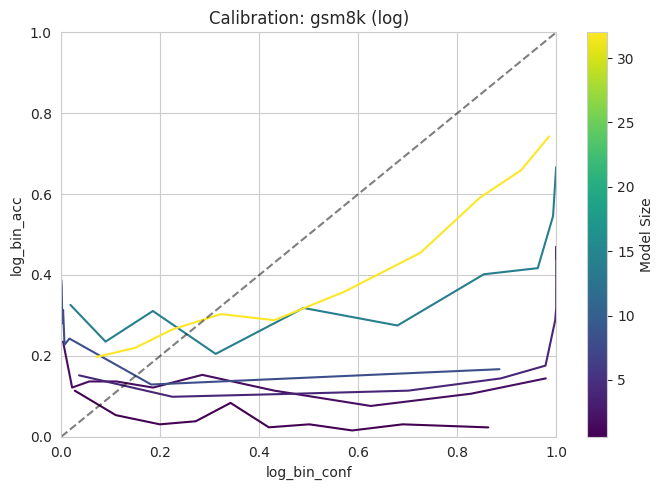

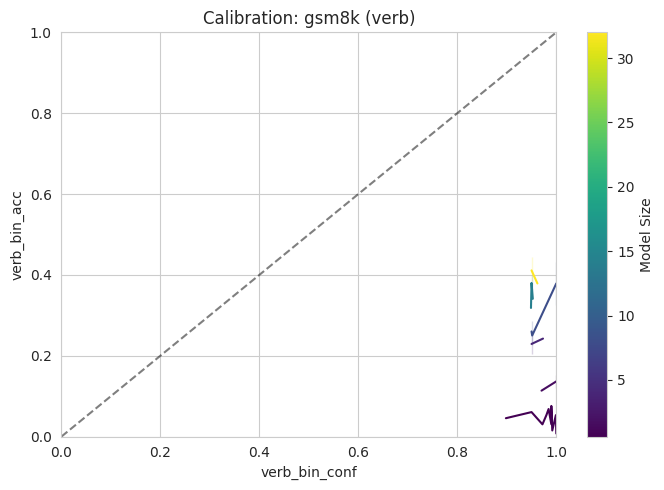

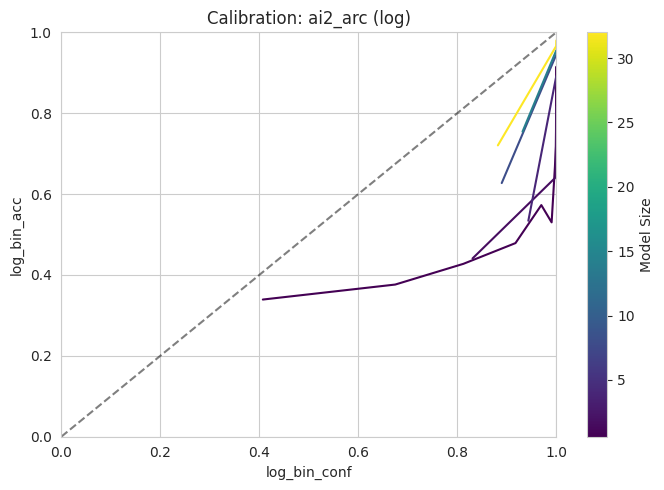

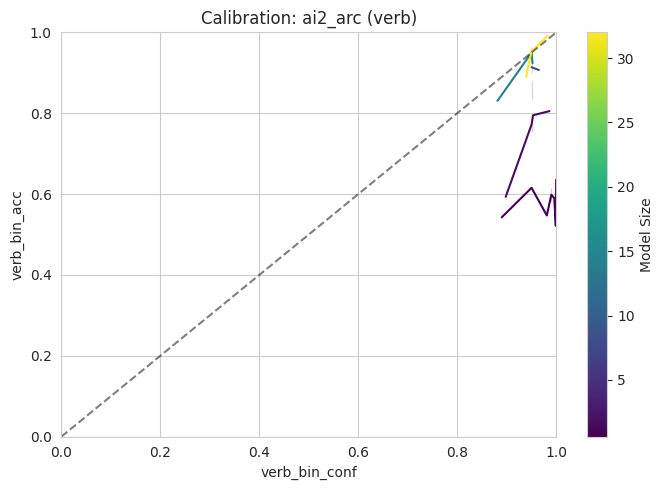

In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_calibration(df, method="verb", dataset=None):
    data = df.reset_index()

    # Optional filtering by dataset
    if dataset is not None:
        data = data[data["dataset"] == dataset]
    else:
        # Fix: Added 'raise' to properly throw the exception
        raise ValueError("Please specify a dataset to plot calibration curves.")

    data = data.explode([f"{method}_bin_conf", f"{method}_bin_acc"])
    
    # Ensure model_size is numeric so the continuous colormap doesn't break
    data["model_size"] = pd.to_numeric(data["model_size"])

    fig, ax = plt.subplots(figsize=(7, 5))

    # 1. Define colormap and normalize based on the model_size range
    cmap = "viridis"
    norm = plt.Normalize(data["model_size"].min(), data["model_size"].max())

    # 2. Plot the data (Fix: Removed trailing 'co')
    sns.lineplot(
        data=data, 
        x=f"{method}_bin_conf", 
        y=f"{method}_bin_acc", 
        hue="model_size", 
        markers="o", 
        legend=False, 
        palette=cmap, 
        hue_norm=norm,
        ax=ax
    )
    
    # 3. Create the ScalarMappable and add the colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Model Size')

    # 4. Standard formatting
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_title(f"Calibration: {dataset} ({method})") # Added a dynamic title
    
    plt.tight_layout()
    plt.show()

# Your function calls will now work as intended
plot_calibration(summary, method="log", dataset="gsm8k")
plot_calibration(summary, method="verb", dataset="gsm8k")
plot_calibration(summary, method="log", dataset="ai2_arc")
plot_calibration(summary, method="verb", dataset="ai2_arc")

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_calibration(df, method="verb", dataset=None):
    data = df.reset_index()

    # optional filtering by dataset
    if dataset is not None:
        data = data[data["dataset"] == dataset]
    else:
        ValueError("Please specify a dataset to plot calibration curves.")

    data = data.explode([f"{method}_bin_conf", f"{method}_bin_acc"])

    sc = sns.lineplot(data=data, x=f"{method}_bin_conf", y=f"{method}_bin_acc", hue="model_size", markers=True, legend=False, palette="viridis)
    ax = plt.gca()
    cbar = plt.colorbar(sc, ax=ax)
    ax.set_xlim(0, 1.1)
    ax.set_ylim(0, 1.1)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    plt.show()

plot_calibration(summary, method="log", dataset="gsm8k")
plot_calibration(summary, method="verb", dataset="gsm8k")
plot_calibration(summary, method="log", dataset="ai2_arc")
plot_calibration(summary, method="verb", dataset="ai2_arc")

SyntaxError: positional argument follows keyword argument (3981225443.py, line 17)

In [10]:
from src import metrics

for dataset in ["gsm8k", "ai2_arc"]:
    files = df.xs(dataset, level="dataset")
    
    for model, row in files.iterrows():
        file = row["folder"] + "/outputs.jsonl"
        output_file = pd.read_json(file, lines=True)
        if dataset == "gsm8k":
            preprocess_gsm8k(output_file)
        elif dataset == "ai2_arc":
            preprocess_ai2_arc(output_file)
        else:
            ValueError("Unknown Dataset")

        for method in ["verb" , "log"]:
            ece_values = metrics.bootstrap_ece(output_file["correct"], output_file[f"{method}_conf"], n_bootstrap=10)
            
            df.loc[(model, dataset),f"{method}_ece"] = ece_values["ece"]
            df.loc[(model, dataset),f"{method}_ece_se"] = ece_values["se"]
            
            df.loc[(model, dataset),f"{method}_brier"] = metrics.brier_score_loss(output_file["correct"], output_file[f"{method}_conf"])
            df.loc[(model, dataset),f"{method}_ap"] = metrics.average_precision_score(output_file["correct"], output_file[f"{method}_conf"])
            
        df.loc[(model, dataset),"acc"] = output_file["correct"].mean()
        df.loc[(model, dataset),"num_samples"] = output_file.shape[0]

In [11]:
df

batch_size  thinking  \
model           dataset                         
Qwen/Qwen3-0.6B ai2_arc          16     False   
                gsm8k            16     False   
Qwen/Qwen3-1.7B ai2_arc          16     False   
                gsm8k            16     False   
Qwen/Qwen3-14B  ai2_arc          32     False   
                gsm8k            16     False   
Qwen/Qwen3-32B  ai2_arc          16     False   
                gsm8k            16     False   
Qwen/Qwen3-4B   ai2_arc           8     False   
                gsm8k             8     False   
Qwen/Qwen3-8B   ai2_arc          10     False   
                gsm8k            10     False   

                                                             system_prompt  \
model           dataset                                                      
Qwen/Qwen3-0.6B ai2_arc  Answer the following multiple-choice question....   
                gsm8k    Solve the following math problem.\n\nPlease re...   
Qwen/Qwen3-1.7B ai2_arc  Answer the following multiple-choice question....   
                gsm8k    Solve the following math problem.\n\nPlease re...   
Qwen/Qwen3-14B  ai2_arc  Answer the following multiple-choice question....   
                gsm8k    Solve the following math problem.\n\nPlease re...   
Qwen/Qwen3-32B  ai2_arc  Answer the following multiple-choice question....   
                gsm8k    Solve the following math problem.\n\nPlease re...   
Qwen/Qwen3-4B   ai2_arc  Answer the following multiple-choice question....   
                gsm8k    Solve the following math problem.\n\nPlease re...   
Qwen/Qwen3-8B   ai2_arc  Answer the following multiple-choice question....   
                gsm8k    Solve the following math problem.\n\nPlease re...   

                               timestamp device max_samples  \
model           dataset                                       
Qwen/Qwen3-0.6B ai2_arc  20260412_173401   cuda        None   
                gsm8k    20260412_172655   cuda        None   
Qwen/Qwen3-1.7B ai2_arc  20260412_174219   cuda        None   
                gsm8k    20260412_173709   cuda        None   
Qwen/Qwen3-14B  ai2_arc  20260412_230850   cuda        None   
                gsm8k    20260412_230544   cuda        None   
Qwen/Qwen3-32B  ai2_arc  20260412_231615   cuda        None   
                gsm8k    20260412_231005   cuda        None   
Qwen/Qwen3-4B   ai2_arc  20260412_181323   cuda        None   
                gsm8k    20260412_180144   cuda        None   
Qwen/Qwen3-8B   ai2_arc  20260412_224931   cuda        None   
                gsm8k    20260412_224214   cuda        None   

                                                       git_commit  \
model           dataset                                             
Qwen/Qwen3-0.6B ai2_arc  6f342c5335676860eb0027d2782c06880a1bf736   
                gsm8k    6f342c5335676860eb0027d2782c06880a1bf736   
Qwen/Qwen3-1.7B ai2_arc  6f342c5335676860eb0027d2782c06880a1bf736   
                gsm8k    6f342c5335676860eb0027d2782c06880a1bf736   
Qwen/Qwen3-14B  ai2_arc  919bb527671ef5c00d1173b42d6034a4667c9e4d   
                gsm8k    919bb527671ef5c00d1173b42d6034a4667c9e4d   
Qwen/Qwen3-32B  ai2_arc  919bb527671ef5c00d1173b42d6034a4667c9e4d   
                gsm8k    919bb527671ef5c00d1173b42d6034a4667c9e4d   
Qwen/Qwen3-4B   ai2_arc  4c5ae904330ede24ab6a356c7cd4a1ae246b58e8   
                gsm8k    4c5ae904330ede24ab6a356c7cd4a1ae246b58e8   
Qwen/Qwen3-8B   ai2_arc  919bb527671ef5c00d1173b42d6034a4667c9e4d   
                gsm8k    919bb527671ef5c00d1173b42d6034a4667c9e4d   

                                                      folder dataset_config  \
model           dataset                                                       
Qwen/Qwen3-0.6B ai2_arc  calibrationData/run_20260412_173401  ARC-Challenge   
                gsm8k    calibrationData/run_20260412_172655            NaN   
Qwen/Qwen3-1.7B ai2_arc  calibrationData/run_20260412_174219  ARC-Challenge   


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

# df = your dataframe
df_new = df.reset_index()  # if model/dataset are index

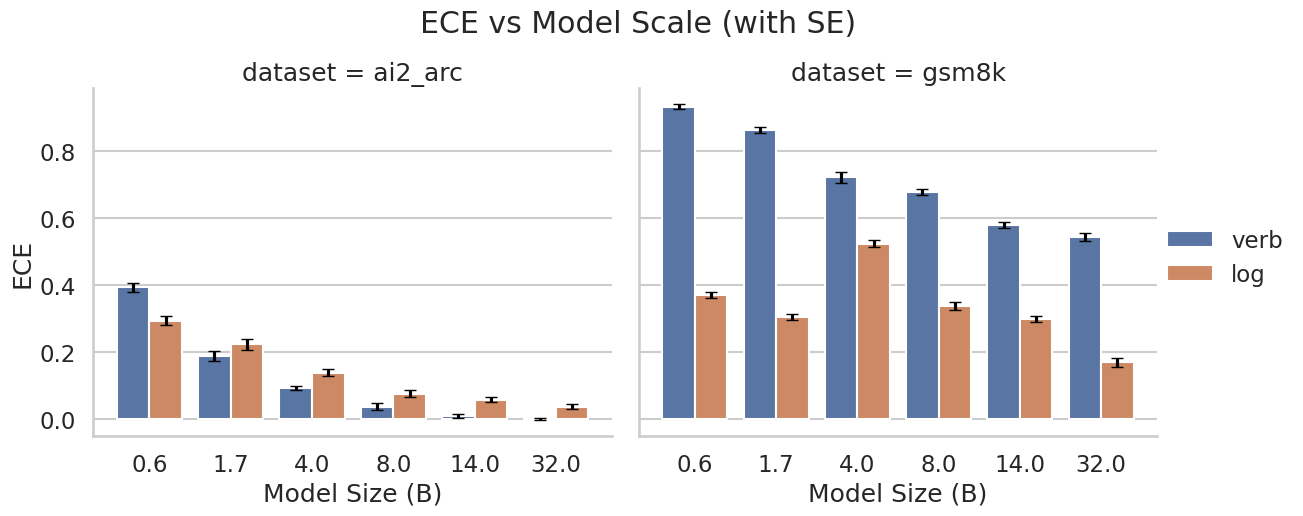

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['verb_brier_se', 'log_brier_se']"

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

for metric in ["ece", "brier", "ap"]:
    
    df_melt = df_new.melt(
        id_vars=["model_size", "dataset"],
        value_vars=[f"verb_{metric}", f"log_{metric}"],
        var_name="type",
        value_name=metric
    )
    
    # melt SE as well
    df_se = df_new.melt(
        id_vars=["model_size", "dataset"],
        value_vars=[f"verb_{metric}_se", f"log_{metric}_se"],
        var_name="type",
        value_name=f"{metric}_se"
    )
    
    # align naming (so verb_ece matches verb_ece_se)
    df_se["type"] = df_se["type"].str.replace(f"_{metric}_se", "")
    df_melt["type"] = df_melt["type"].str.replace(f"_{metric}", "")
    
    # merge values + SE
    df_plot = df_melt.merge(
        df_se,
        on=["model_size", "dataset", "type"]
    )
    
    g = sns.FacetGrid(
        df_plot,
        col="dataset",
        height=5,
        aspect=1.2
    )
    
    def bar_with_error(data, **kwargs):
        ax = plt.gca()
        
        sns.barplot(
            data=data,
            x="model_size",
            y=metric,
            hue="type",
            ax=ax,
            capsize=0.2
        )
        
        # add manual error bars
        for i, row in data.iterrows():
            x_pos = list(sorted(data["model_size"].unique())).index(row["model_size"])
            
            # offset for hue (2 bars per group)
            offset = -0.2 if row["type"] == "verb" else 0.2
            
            ax.errorbar(
                x=x_pos + offset,
                y=row[metric],
                yerr=row[f"{metric}_se"],
                fmt='none',
                c='black',
                capsize=4
            )
    
    g.map_dataframe(bar_with_error)
    
    g.add_legend()
    g.set_axis_labels("Model Size (B)", metric.upper())
    g.fig.suptitle(f"{metric.upper()} vs Model Scale (with SE)", y=1.05)
    
    plt.show()

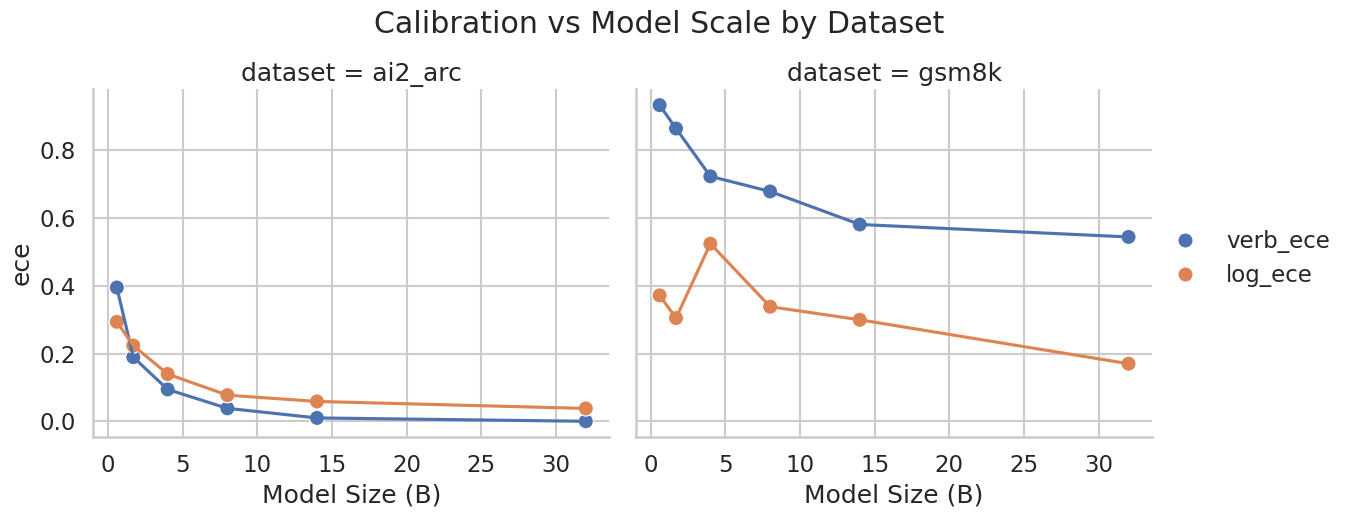

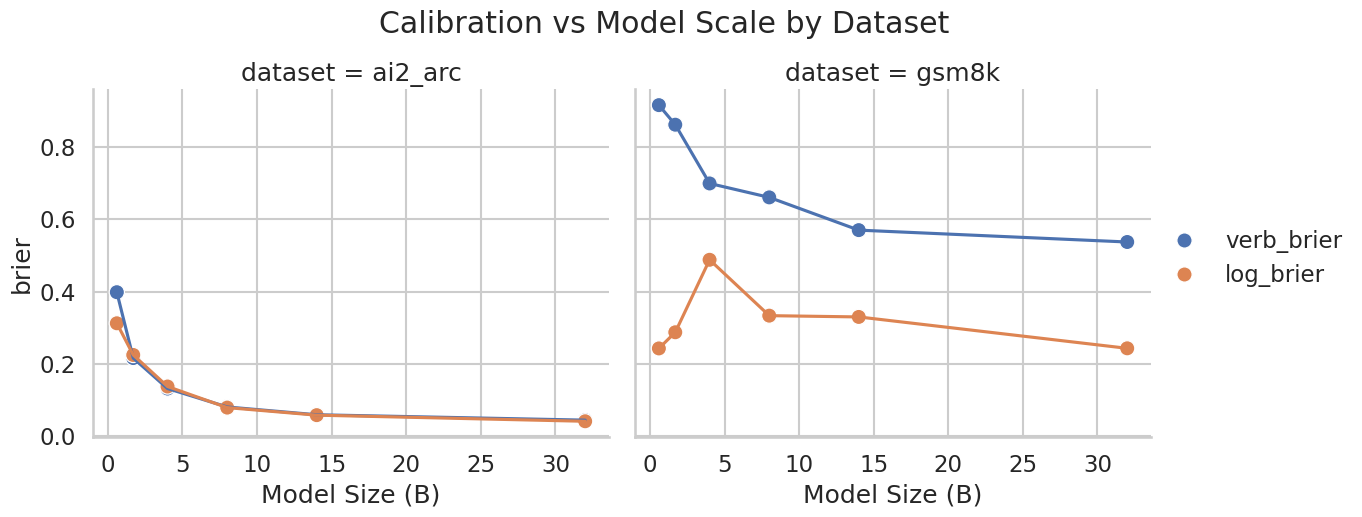

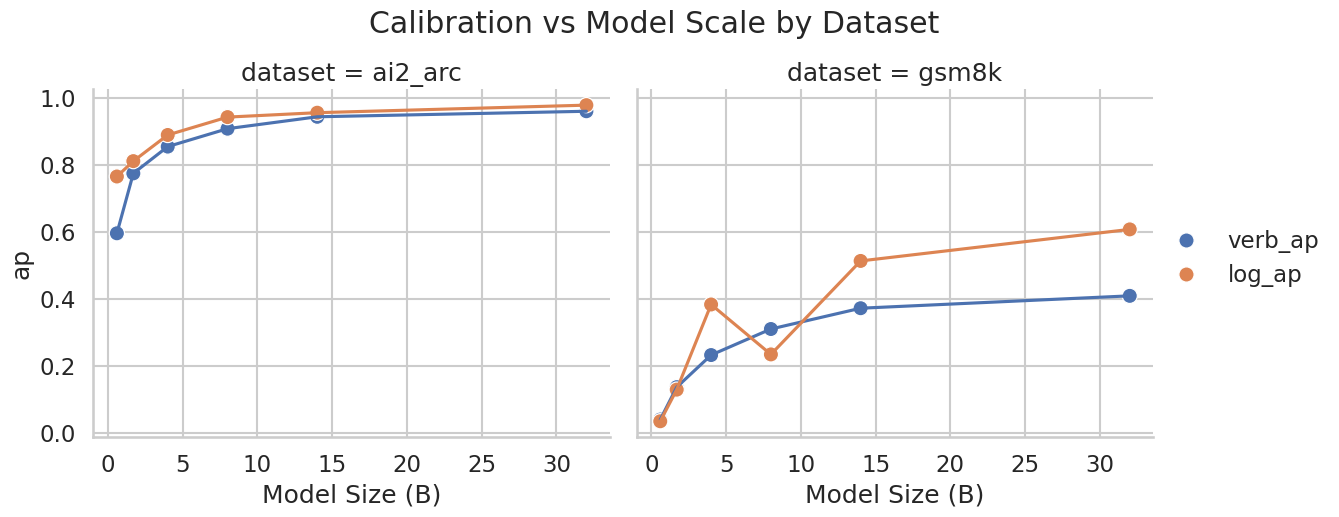

In [15]:
for metric in ["ece", "brier", "ap"]:
    df_melt = df_new.melt(
        id_vars=["model_size", "dataset"],
        value_vars=[f"verb_{metric}", f"log_{metric}"],
        var_name="metric",
        value_name=metric
    )
    
    g = sns.FacetGrid(
        df_melt,
        col="dataset",
        height=5,
        aspect=1.2
    )
    
    g.map_dataframe(
        sns.scatterplot,
        x="model_size",
        y=metric,
        hue="metric",
        s=120
    )
    
    g.map_dataframe(
        sns.lineplot,
        x="model_size",
        y=metric,
        hue="metric",
        legend=False
    )
    
    g.add_legend()
    g.set_axis_labels("Model Size (B)", metric)
    g.fig.suptitle("Calibration vs Model Scale by Dataset", y=1.05)
    
    plt.show()

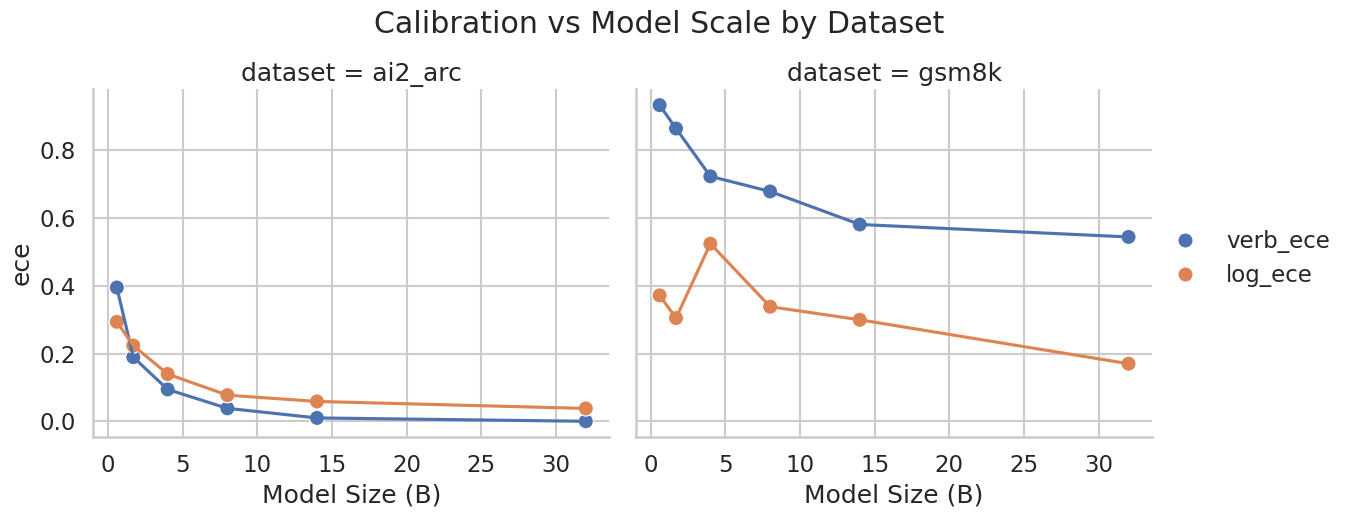

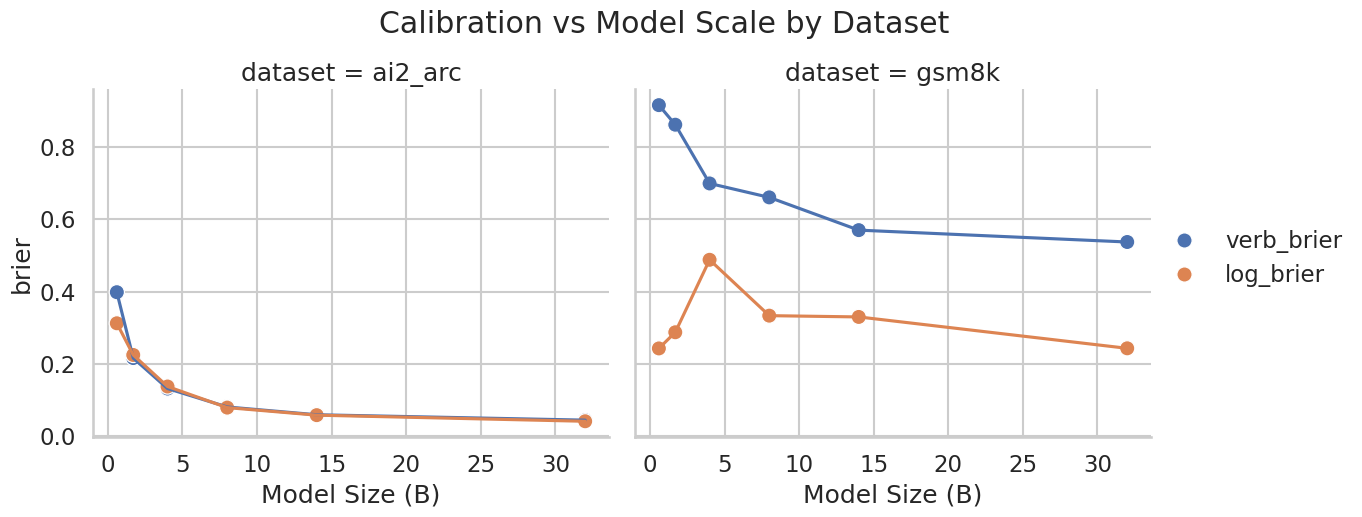

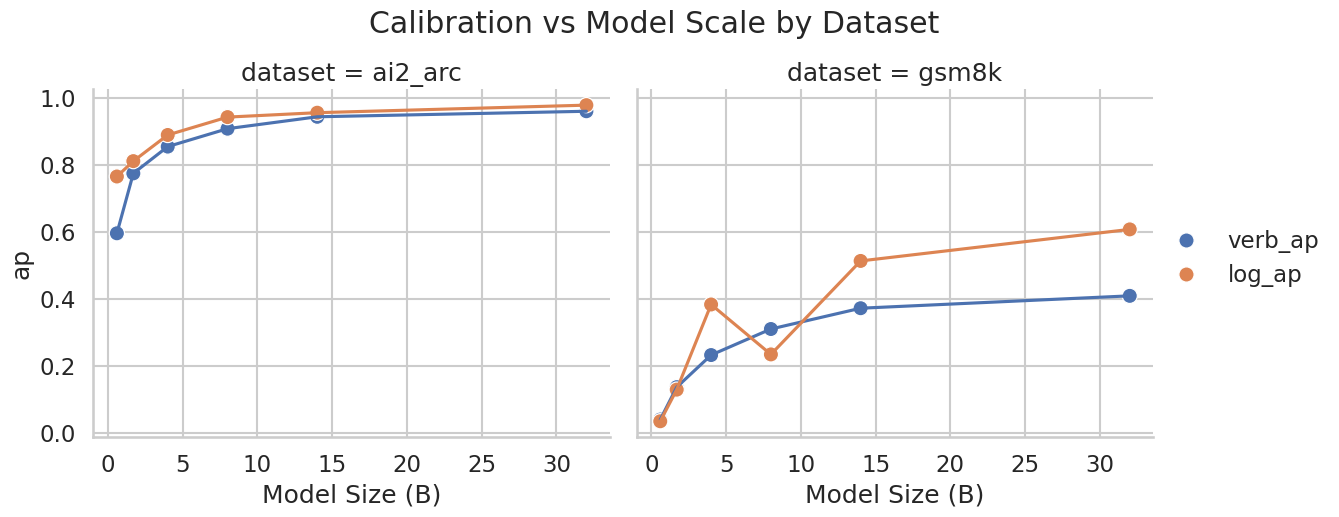

In [ ]:
for metric in ["ece", "brier", "ap"]:
    df_melt = df_new.melt(
        id_vars=["model_size", "dataset"],
        value_vars=[f"verb_{metric}", f"log_{metric}"],
        var_name="metric",
        value_name=metric
    )
    
    g = sns.FacetGrid(
        df_melt,
        col="dataset",
        height=5,
        aspect=1.2
    )
    
    g.map_dataframe(
        sns.scatterplot,
        x="model_size",
        y=metric,
        hue="metric",
        s=120
    )
    
    g.map_dataframe(
        sns.lineplot,
        x="model_size",
        y=metric,
        hue="metric",
        legend=False
    )
    
    g.add_legend()
    g.set_axis_labels("Model Size (B)", metric)
    g.fig.suptitle("Calibration vs Model Scale by Dataset", y=1.05)
    
    plt.show()

In [30]:
df_ece = df_new.melt(
    id_vars=["model_size", "dataset", "acc"],
    value_vars=["verb_ece", "log_ece"],
    var_name="metric",
    value_name="ece"
)
df_ece

,model_size,dataset,acc,metric,ece
0,0.6,ai2_arc,0.584471,verb_ece,0.394369
1,0.6,gsm8k,0.043973,verb_ece,0.931592
2,1.7,ai2_arc,0.759386,verb_ece,0.189309
3,1.7,gsm8k,0.134193,verb_ece,0.862820
4,14.0,ai2_arc,0.935154,verb_ece,0.010239
5,14.0,gsm8k,0.369977,verb_ece,0.580167
6,32.0,ai2_arc,0.952218,verb_ece,0.000401
7,32.0,gsm8k,0.407885,verb_ece,0.543306
8,4.0,ai2_arc,0.855802,verb_ece,0.094198
9,4.0,gsm8k,0.230478,verb_ece,0.721842


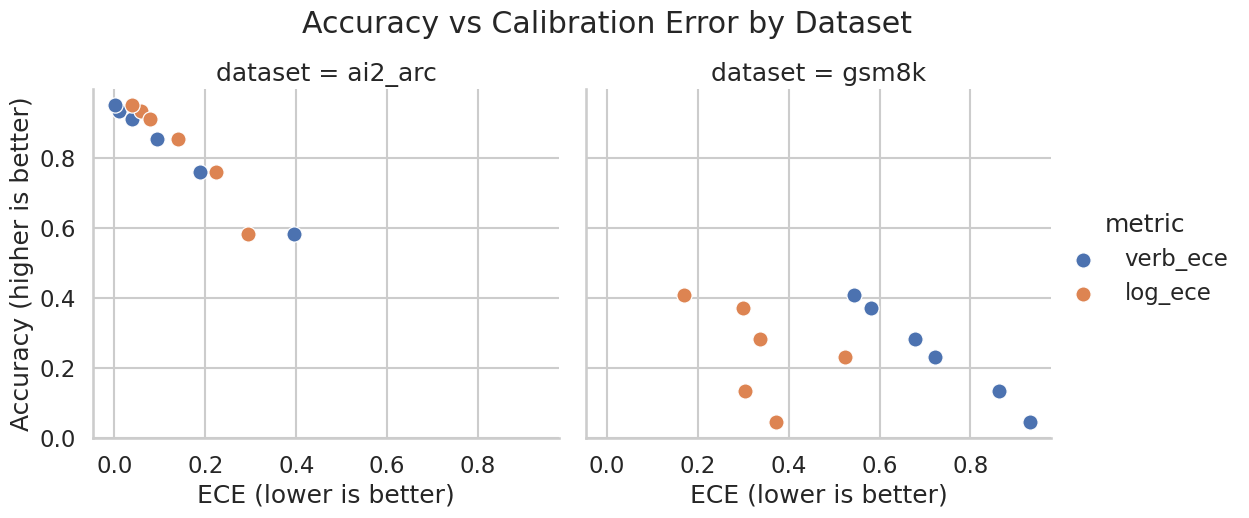

In [31]:
g = sns.FacetGrid(
    df_ece,
    col="dataset",
    hue="metric",
    height=5,
    aspect=1.1
)

g.map_dataframe(
    sns.scatterplot,
    x="ece",
    y="acc",
    s=120
)

g.add_legend()

g.set_axis_labels("ECE (lower is better)", "Accuracy (higher is better)")
g.fig.suptitle("Accuracy vs Calibration Error by Dataset", y=1.05)

plt.show()

In [32]:
df_thinking

,,batch_size,thinking,system_prompt,timestamp,device,max_samples,git_commit,folder,dataset_config,model_size
model,dataset,,,,,,,,,,
Qwen/Qwen3-0.6B,gsm8k,30,True,Solve the following math problem.\n\nPlease re...,20260414_115919,cuda,None,919bb527671ef5c00d1173b42d6034a4667c9e4d,calibrationData/run_20260414_115919,NaN,0.6


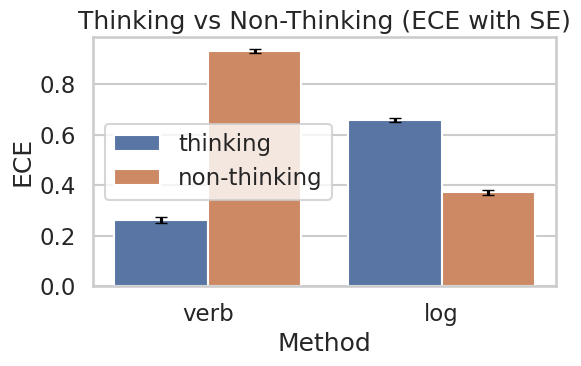

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---- get the single thinking row ----
idx = df_thinking.index[0]   # (model, dataset)
row_thinking = df_thinking.loc[idx]

# ---- get corresponding non-thinking row ----
row_base = df.loc[idx]

# ---- build plotting dataframe ----
df_plot = pd.DataFrame([
    {
        "type": "thinking",
        "verb_ece": row_thinking["verb_ece"],
        "verb_ece_se": row_thinking["verb_ece_se"],
        "log_ece": row_thinking["log_ece"],
        "log_ece_se": row_thinking["log_ece_se"],
    },
    {
        "type": "non-thinking",
        "verb_ece": row_base["verb_ece"],
        "verb_ece_se": row_base["verb_ece_se"],
        "log_ece": row_base["log_ece"],
        "log_ece_se": row_base["log_ece_se"],
    }
])

# ---- reshape ----
df_plot = pd.melt(
    df_plot,
    id_vars="type",
    value_vars=["verb_ece", "log_ece"],
    var_name="method",
    value_name="ece"
)

# add SE
df_plot["ece_se"] = df_plot.apply(
    lambda row: (
        row_thinking[f"{row['method']}_se"]
        if row["type"] == "thinking"
        else row_base[f"{row['method']}_se"]
    ),
    axis=1
)

# clean method names
df_plot["method"] = df_plot["method"].str.replace("_ece", "")

# ---- plotting ----
plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=df_plot,
    x="method",
    y="ece",
    hue="type",
    capsize=0.2
)

# manual error bars
x_order = ["verb", "log"]

for _, row in df_plot.iterrows():
    x_pos = x_order.index(row["method"])
    offset = -0.2 if row["type"] == "thinking" else 0.2
    
    ax.errorbar(
        x=x_pos + offset,
        y=row["ece"],
        yerr=row["ece_se"],
        fmt='none',
        c='black',
        capsize=4
    )

plt.ylabel("ECE")
plt.xlabel("Method")
plt.title("Thinking vs Non-Thinking (ECE with SE)")
plt.legend(title="")

plt.tight_layout()
plt.show()

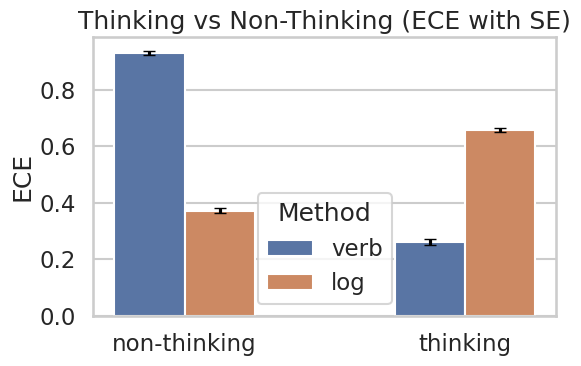

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---- get rows ----
idx = df_thinking.index[0]
row_thinking = df_thinking.loc[idx]
row_base = df.loc[idx]

# ---- build dataframe ----
df_plot = pd.DataFrame([
    {
        "type": "non-thinking",
        "verb_ece": row_base["verb_ece"],
        "verb_ece_se": row_base["verb_ece_se"],
        "log_ece": row_base["log_ece"],
        "log_ece_se": row_base["log_ece_se"],
    },
    {
        "type": "thinking",
        "verb_ece": row_thinking["verb_ece"],
        "verb_ece_se": row_thinking["verb_ece_se"],
        "log_ece": row_thinking["log_ece"],
        "log_ece_se": row_thinking["log_ece_se"],
    },
])

# reshape
df_plot = pd.melt(
    df_plot,
    id_vars="type",
    value_vars=["verb_ece", "log_ece"],
    var_name="method",
    value_name="ece"
)

# add SE
df_plot["ece_se"] = df_plot.apply(
    lambda row: (
        row_thinking[f"{row['method']}_se"]
        if row["type"] == "thinking"
        else row_base[f"{row['method']}_se"]
    ),
    axis=1
)

df_plot["method"] = df_plot["method"].str.replace("_ece", "")

# ---- plot ----
plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=df_plot,
    x="type",          # switched
    y="ece",
    hue="method",      # switched
    capsize=0.2,
    width=0.5
)

# manual error bars
x_order = ["non-thinking", "thinking"]

for _, row in df_plot.iterrows():
    x_pos = x_order.index(row["type"])
    offset = -0.125 if row["method"] == "verb" else 0.125
    
    ax.errorbar(
        x=x_pos + offset,
        y=row["ece"],
        yerr=row["ece_se"],
        fmt='none',
        c='black',
        capsize=4
    )

plt.xlabel("")
plt.ylabel("ECE")
plt.title("Thinking vs Non-Thinking (ECE with SE)")
plt.legend(title="Method")

plt.tight_layout()
plt.show()